In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/mahmoudramadan155/ML/main/labs/dl/Churn_Modelling.csv"

df = pd.read_csv(url)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.columns = df.columns.str.strip().str.lower()

possible_targets = ['exited', 'churn', 'target', 'class']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]

print(f"Column Chosen: '{target_col}'")

if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0, 'true': 1, 'false': 0})

for col in df.columns:
    if 'id' in col or 'rownumber' in col or 'surname' in col:
        df = df.drop(columns=[col])

Column Chosen: 'exited'


In [10]:
df = df.dropna()

X = df.drop(columns=[target_col])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

In [11]:
# Train Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Neural Network Architecture
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # 1 Neuron + Sigmoid for Binary Classification
])

In [13]:
# Model Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Crossentropy for Classification
    metrics=['accuracy']
)

In [14]:
# Model Training
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8075 - loss: 0.4471 - val_accuracy: 0.8637 - val_loss: 0.3709
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8474 - loss: 0.3729 - val_accuracy: 0.8737 - val_loss: 0.3298
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8542 - loss: 0.3514 - val_accuracy: 0.8788 - val_loss: 0.3258
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8606 - loss: 0.3428 - val_accuracy: 0.8763 - val_loss: 0.3130
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.3395 - val_accuracy: 0.8737 - val_loss: 0.3117
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8604 - loss: 0.3332 - val_accuracy: 0.8763 - val_loss: 0.3113
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.3328 - val_accuracy: 0.8737 - val_loss: 0.3098
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.3270 - val_accuracy: 0.

In [15]:
# Model Evaluation
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int) # تحويل الاحتمالات إلى 0 أو 1

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Test Accuracy: 84.10%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1593
           1       0.63      0.52      0.57       407

    accuracy                           0.84      2000
   macro avg       0.76      0.72      0.74      2000
weighted avg       0.83      0.84      0.84      2000



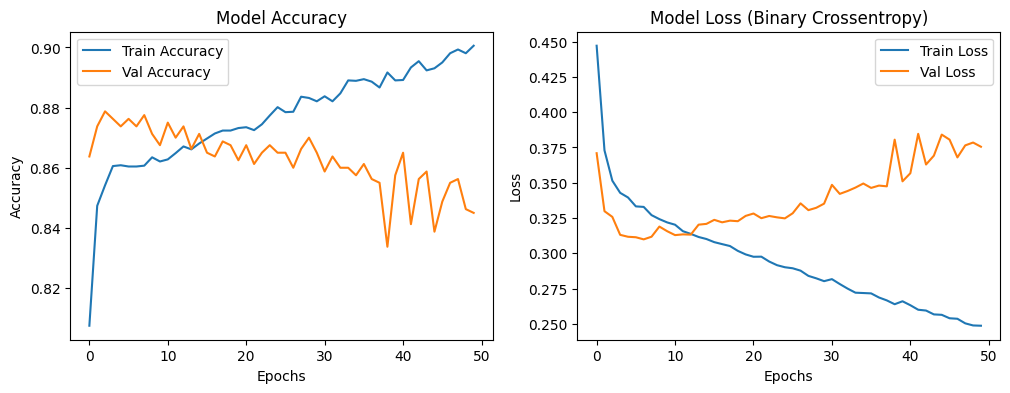

In [16]:
# Plot Accuracy and Loss Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Binary Crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()